In [3]:
import pandas as pd
data=pd.read_excel(r'C:\Users\Venugopal\OneDrive\Documents\Batch_469\Online Retail.xlsx')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB



### Category	Key EDA Questions to Answer
### Data Cleaning	
### 1. How many missing values are there in the CustomerID and Description columns, and how should they be handled?
### 2. How can you identify and handle returns (transactions with negative Quantity)?
### 3. How do you calculate the Total Sales for each transaction (e.g., Quantity * UnitPrice)?
### Sales & Trends	
### 4. What are the Top 10 selling products by quantity and by total revenue?
### 5. Analyze and plot the monthly sales trend over the year to identify seasonality.
### 6. Which countries generate the most revenue?
### Customer Insights	
### 7. Identify the Top 5 Customers based on their total spending.
### 8. Perform a basic Recency, Frequency, Monetary (RFM) analysis to segment customers.

In [7]:
print(data.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [8]:
data.dropna(subset=['CustomerID', 'Description'], inplace=True)

In [9]:
print(data.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [11]:
df_return=data[data['Quantity'] < 0]

In [12]:
df_sales=data[~data['Quantity'] < 0]

In [13]:
df_sales.shape

(397924, 8)

In [14]:
df_return.shape

(8905, 8)

In [18]:

df_sales['TotalSales'] = df_sales['Quantity'] * df_sales['UnitPrice']

C:\Users\Venugopal\AppData\Local\Temp\ipykernel_13948\2635987774.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sales['TotalSales'] = df_sales['Quantity'] * df_sales['UnitPrice']


In [16]:
print(df_sales[['Quantity', 'UnitPrice', 'TotalSales']].head())

   Quantity  UnitPrice  TotalSales
0         6       2.55       15.30
1         6       3.39       20.34
2         8       2.75       22.00
3         6       3.39       20.34
4         6       3.39       20.34


In [20]:
top_revenue_products = df_sales.groupby('Description')['TotalSales'].sum().reset_index()
top_revenue_products

,Description,TotalSales
0,4 PURPLE FLOCK DINNER CANDLES,270.76
1,50'S CHRISTMAS GIFT BAG LARGE,2272.25
2,DOLLY GIRL BEAKER,2759.50
3,I LOVE LONDON MINI BACKPACK,1454.00
4,I LOVE LONDON MINI RUCKSACK,4.15
...,...,...
3872,ZINC T-LIGHT HOLDER STARS SMALL,3879.98
3873,ZINC TOP 2 DOOR WOODEN SHELF,169.50
3874,ZINC WILLIE WINKIE CANDLE STICK,2176.95
3875,ZINC WIRE KITCHEN ORGANISER,156.80


In [21]:
top_revenue_products.sort_values(
    by='TotalSales', 
    ascending=False
)

,Description,TotalSales
2319,"PAPER CRAFT , LITTLE BIRDIE",168469.600
2767,REGENCY CAKESTAND 3 TIER,142592.950
3698,WHITE HANGING HEART T-LIGHT HOLDER,100448.150
1762,JUMBO BAG RED RETROSPOT,85220.780
1992,MEDIUM CERAMIC TOP STORAGE JAR,81416.730
...,...,...
2639,PURPLE FRANGIPANI HAIRCLIP,0.850
3556,VINTAGE BLUE TINSEL REEL,0.840
2933,SET 12 COLOURING PENCILS DOILEY,0.650
1628,HEN HOUSE W CHICK IN NEST,0.420


In [22]:
top_10_products = top_revenue_products.head(10)

C:\Users\Venugopal\AppData\Local\Temp\ipykernel_13948\873023070.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='TotalSales', ylabel='Description'>

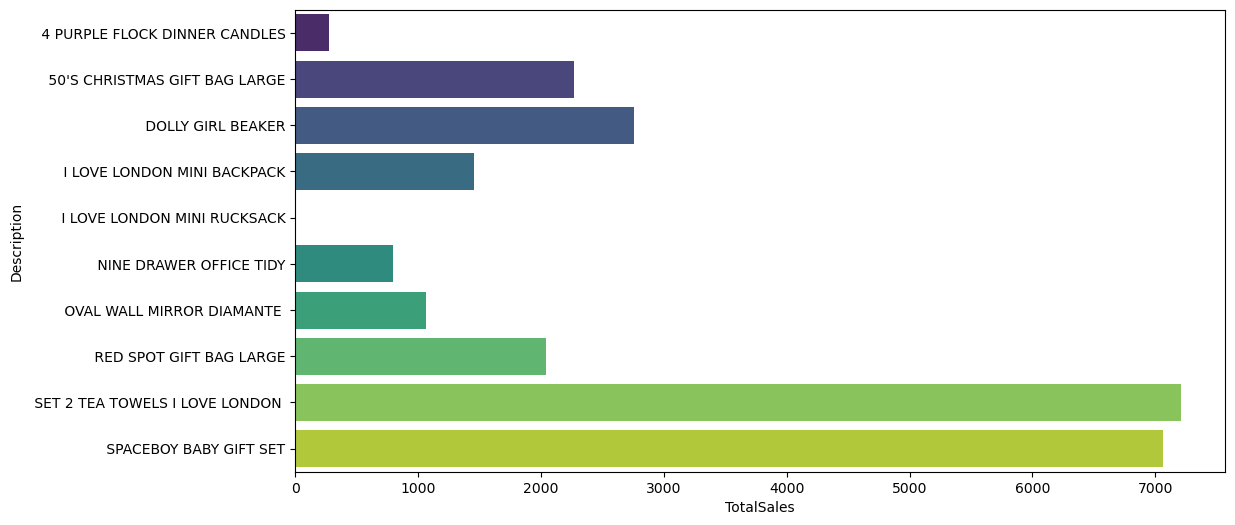

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(
    x='TotalSales', 
    y='Description', 
    data=top_10_products, 
    palette='viridis'
)

In [25]:
df_sales['YearMonth'] = df_sales['InvoiceDate'].dt.to_period('M')

C:\Users\Venugopal\AppData\Local\Temp\ipykernel_13948\2905210039.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sales['YearMonth'] = df_sales['InvoiceDate'].dt.to_period('M')


In [26]:
monthly_sales = df_sales.groupby('YearMonth')['TotalSales'].sum().reset_index()

In [27]:
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

<Axes: xlabel='YearMonth', ylabel='TotalSales'>

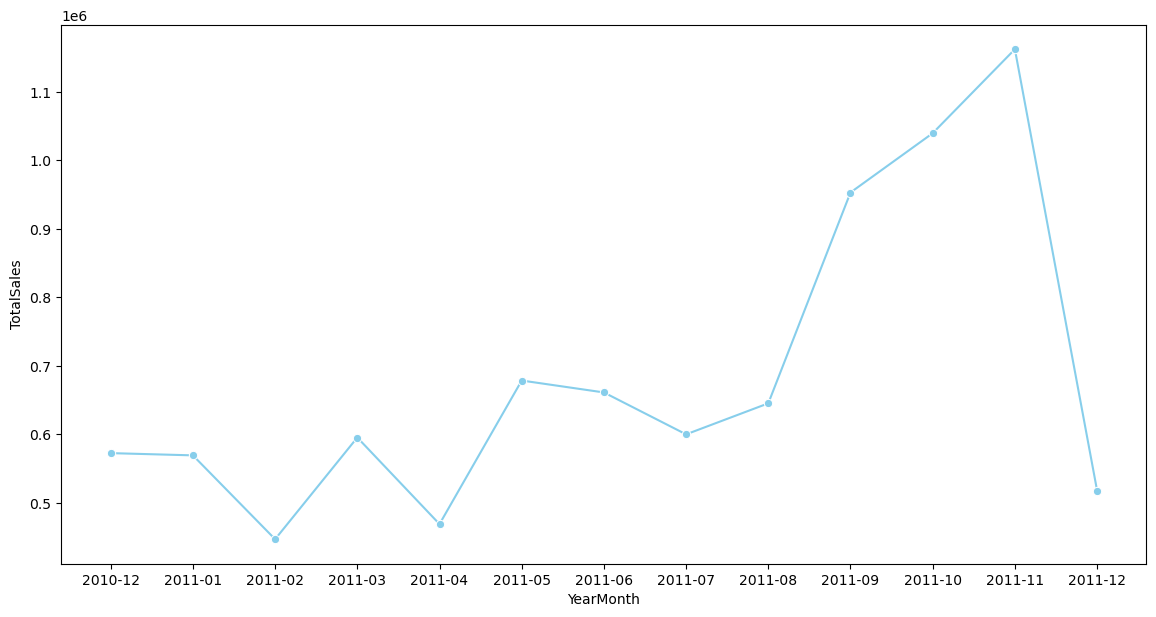

In [28]:
plt.figure(figsize=(14, 7))
sns.lineplot(
    x='YearMonth', 
    y='TotalSales', 
    data=monthly_sales, 
    marker='o',
    color='skyblue'
)

In [29]:
latest_date = df_sales['InvoiceDate'].max()
snapshot_date = latest_date + pd.Timedelta(days=1)

In [30]:
latest_date,snapshot_date

(Timestamp('2011-12-09 12:50:00'), Timestamp('2011-12-10 12:50:00'))

In [33]:
df_sales['Recency']=df_sales['InvoiceDate'].apply( lambda x: (snapshot_date -x).days)

C:\Users\Venugopal\AppData\Local\Temp\ipykernel_13948\750537726.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sales['Recency']=df_sales['InvoiceDate'].apply( lambda x: (snapshot_date -x).days)


In [34]:
df_sales['Recency']

0         374
1         374
2         374
3         374
4         374
         ... 
541904      1
541905      1
541906      1
541907      1
541908      1
Name: Recency, Length: 397924, dtype: int64